In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline
from sklearn.metrics import r2_score

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

import imageio
import os
import shutil
import sys

PROJECT_ROOT = "../"
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.loaders import load_all_ploidy_liquid, load_all_ploidy, load_adaptive_stability_results, load_adaptive_stability_results_liquid, load_ensemble

In [2]:
### Error areas x ###
def return_stats(vec, interv):
    means =[]
    stds = []
    for i in range(len(interv)-1):
        provv = []
        for j in range(len(vec)):
            provv.append(np.where(np.logical_and(vec[j]>interv[i],vec[j]<=interv[i+1]))[0])
        provv = np.concatenate(provv)
        means.append(np.mean(provv))
        stds.append(np.std(provv))
    
    return np.array(means), np.array(stds)

def reconstruct_ymean(mm, space):
    x = []
    for i in range(int(max(mm))):
        p0 = np.where(mm<=i)[0][-1]
        p1 = np.where(mm>i)[0][0]
        slope = space/(mm[p1]-mm[p0])
        x.append(interv_0[p0]+slope*1)
    return np.array(x)

def running_slope(x, skip):
    vec = []
    for i in range(skip, len(x)-skip-1):
        vec.append((x[i+skip]-x[i])/skip)
    return np.array(vec)

### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = []
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = np.quantile(arr, 0.5)
            stds.append([np.quantile(arr, 0.159), np.quantile(arr, 0.841)]) # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds.append([np.nan, np.nan])
            
    return np.array(means), np.array(stds)

def plot_stats_elementwise(x, ax, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(x)
    
    ax.plot(np.arange(len(means)), means, color=color, lw=lw, label=label)
    ax.fill_between(np.arange(len(means)) ,stds[:,0], stds[:,1], color=color, alpha=alpha)

In [6]:
ens = load_ensemble("ensemble_results")

In [21]:
ens[1][0].keys()

dict_keys(['tumor_density', 'mut_S', 'mut_I', 'r', 'outcome_code', 'mu', 'act_M', 'act_O', 'n_chrs', 'mut_HK', 'mut_O', 'act_S', 'act_HK', 'death_density', 'm', 'mut_M', 'act_I'])

In [37]:
2.17*0.015

0.032549999999999996

In [40]:
1-(1-0.038)**10

0.3211861099415607

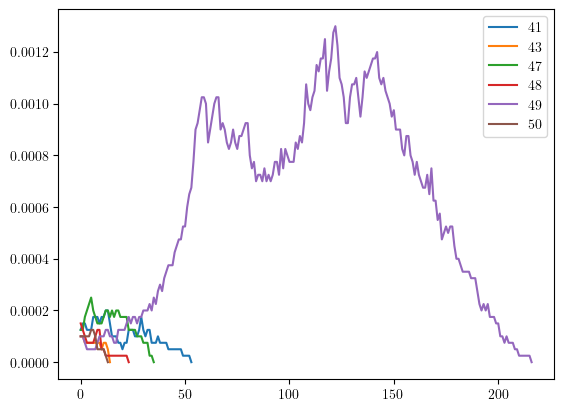

In [36]:
for i in range(40,50):
    if ens[1][i]['outcome_code']==0:
        plt.plot(ens[1][i]['tumor_density'], label=str(i+1))
plt.legend()

In [4]:
data_l = load_all_ploidy_liquid()
data_s = load_all_ploidy()

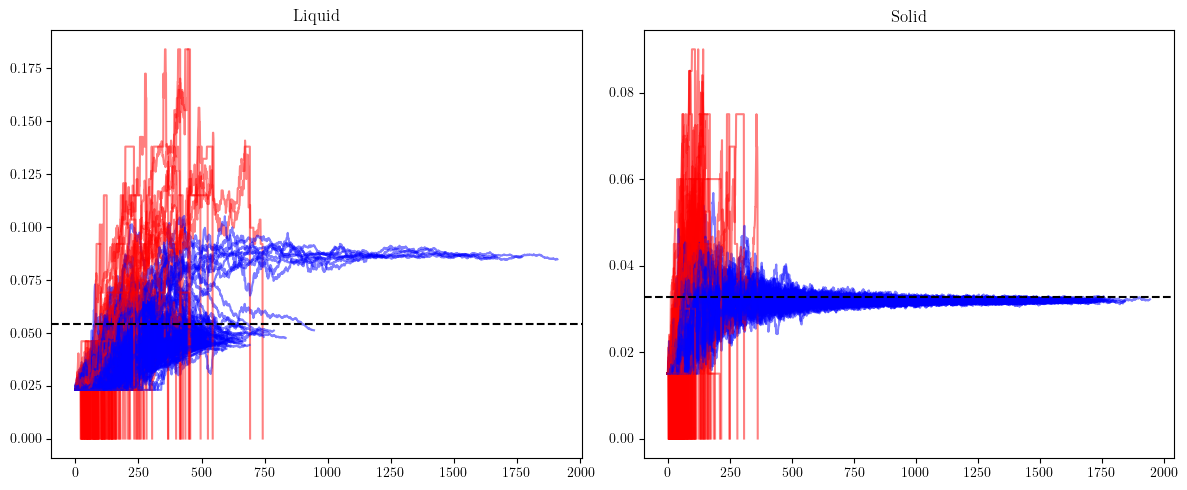

In [5]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

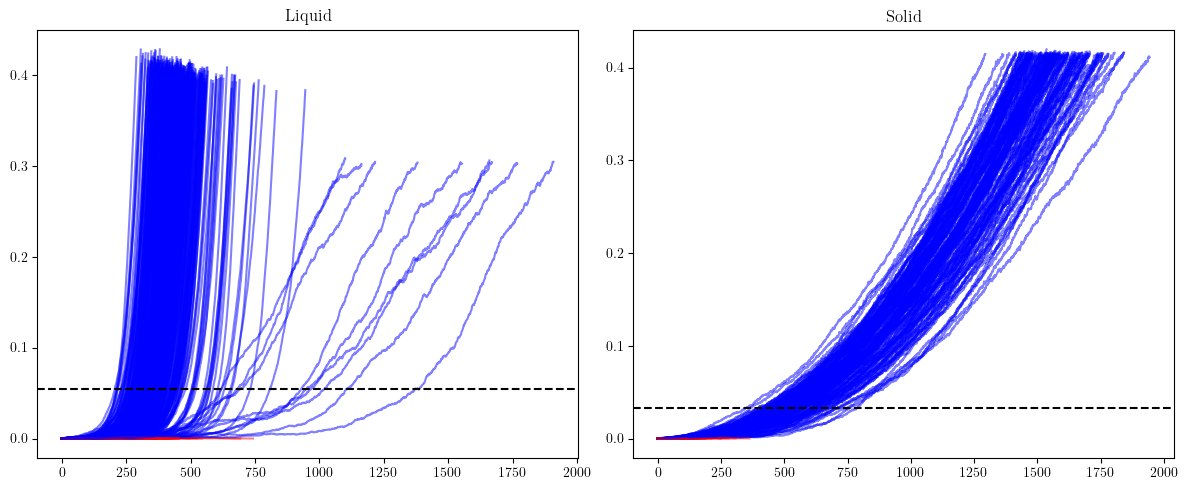

In [7]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

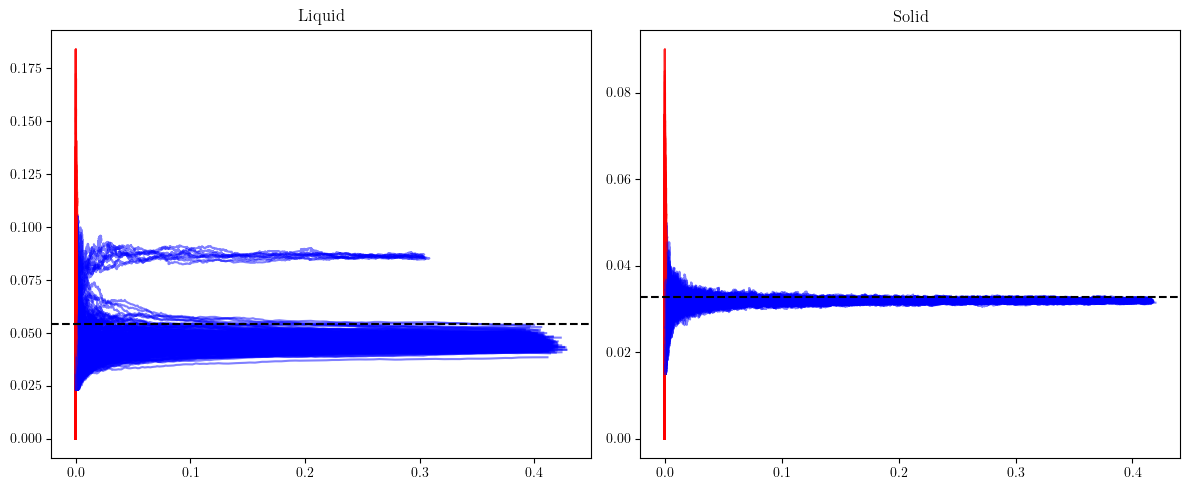

In [8]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

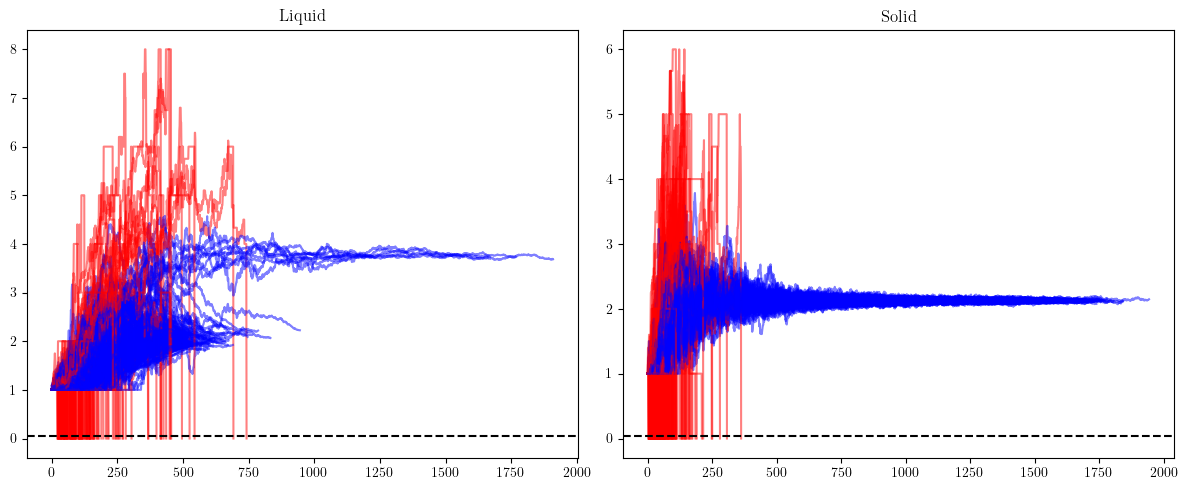

In [9]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

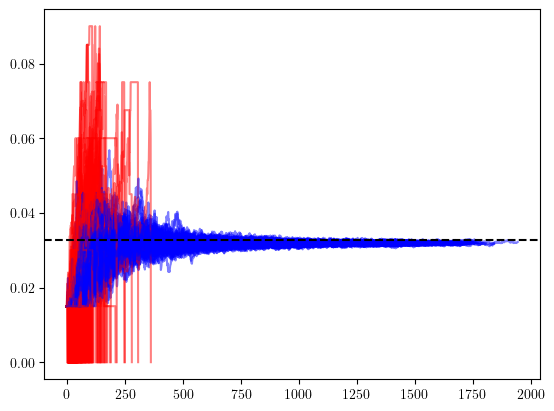

In [10]:
for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

plt.axhline(0.032614, color="k", ls="--")

In [20]:
1-(1/2)**(1/10)

0.06696700846319259

In [ ]:
1-((3/)**(1/10))

-0.04137974399241062

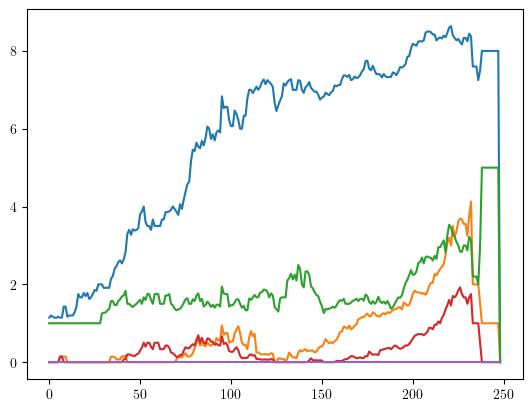

In [9]:
index = 1
plt.plot(data_s['Diploid'][1][index]['act_O'])
plt.plot(data_s['Diploid'][1][index]['act_S'])
plt.plot(data_s['Diploid'][1][index]['act_I'])
plt.plot(data_s['Diploid'][1][index]['act_M'])
plt.plot(data_s['Diploid'][1][index]['act_HK'])

In [10]:
stab = load_adaptive_stability_results()
stabl = load_adaptive_stability_results_liquid()

In [67]:
((1-0.15)**10)*(1-((1-0.15)**10))


0.15811487325620827

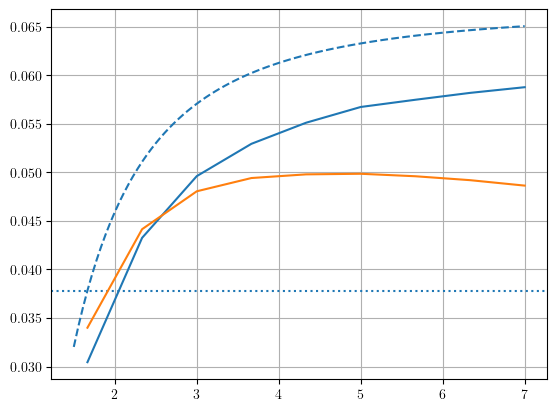

In [68]:
x = np.linspace(1.5,7,100)

def th_pred(x):
    #return (1-((1+1/x)/2)**0.1)
    return 1 - ((1/2)*(1+(1/x)**2))**0.1
def th_b(x, lb=0):
    a = []
    for xi in x:
        a.append(compute_asymptotic_limit(10,10,xi,lb)['asymp_mu_analytical'])
    return np.array(a)
def pdeath(x):
    return 1-(1-x)**(10)

#plt.plot(x, pdeath(th_pred(x)))
plt.plot(stab['rmax_norm'], stab['stable_dmu']*10, color="C0")
plt.plot(x, th_pred(x), color="C0", ls="--")
plt.axhline(compute_asymptotic_limit(10,10,0.017)['asymp_mu_analytical'], c="C0", ls=":")
plt.plot(stabl['rmax_norm'], stabl['stable_dmu']*10, color="C1")

plt.grid()

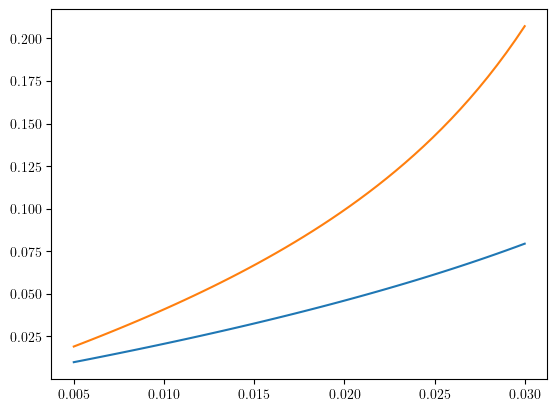

In [56]:
xmu = np.linspace(0.005, 0.03)
plt.plot(xmu, th_b(xmu))
plt.plot(xmu, th_b(xmu,lb=1))

In [30]:
from scripts.calculate_asymptotic_theory import compute_asymptotic_limit

In [35]:
compute_asymptotic_limit(10,10,0.015)['asymp_mu_analytical']

0.032613709914529505

In [ ]:
import numpy as np


# ---------------------------------------------------------------------------
# Transition probabilities
# ---------------------------------------------------------------------------

def p_clone(k, dmu, N_I, N_HK):
    """P_clone^(k): faithful replication, no mutation at any locus."""
    return (1 - k * dmu) ** (N_HK + N_I - k)


def p_promote(k, dmu, N_I, N_HK):
    """P_up^(k): survive HK, hit exactly one remaining I gene."""
    if k >= N_I:
        return 0.0
    return (N_I - k) * k * dmu * (1 - k * dmu) ** (N_HK + N_I - k - 1)


def p_survive(k, dmu, N_HK):
    """P_s^(k): no HK gene hit."""
    return (1 - k * dmu) ** N_HK


def p_dead(k, dmu, N_HK):
    """P_d^(k): at least one HK gene hit."""
    return 1.0 - p_survive(k, dmu, N_HK)


# ---------------------------------------------------------------------------
# phi factors (equal rates: all cancer-vs-cancer Moran = 1/2)
# ---------------------------------------------------------------------------

def compute_phi_all(f, p_D, f_W, beta):
    """
    phi_k = p_D + f_W * beta + 0.5 * F  (same for all k when r_k = r_max)
    phi_k^{!=k} = phi_k - f_k / 2
    Returns phi (scalar), phi_ns (array of length N_I).
    """
    F   = f.sum()
    phi = p_D + f_W * beta + 0.5 * F        # scalar, same for all k
    phi_ns = phi - 0.5 * f                   # array, one entry per class
    return phi, phi_ns


# ---------------------------------------------------------------------------
# Stationary dead fraction from d(p_D)/dt = 0
#
# sum_k f_k [ phi_k * delta_k - p_D * sigma_k ] = 0
# => p_D = sum_k f_k * phi_k * delta_k / sum_k f_k * sigma_k
# ---------------------------------------------------------------------------

def stationary_p_D(f, p_D, f_W, beta, dmu, N_I, N_HK):
    phi, _ = compute_phi_all(f, p_D, f_W, beta)   # phi same for all k
    num, den = 0.0, 0.0
    for idx in range(N_I):
        k = idx + 1
        num += f[idx] * phi * p_dead(k, dmu, N_HK)
        den += f[idx] * p_survive(k, dmu, N_HK)
    if den < 1e-30:
        return p_D
    return np.clip(num / den, 0.0, 1.0)


# ---------------------------------------------------------------------------
# Residual of the stationary ODE for class k
#
# From dc_k/dt = 0 (divided by r_max * N, which cancels):
#
#   f_k * [ phi_ns_k * alpha_k - (f_k/2) * delta_k - phi_k * gamma_k ]
#   + influx_{k-1}
#   = 0
#
# Rearranged as a function of f_k alone (given all other quantities):
#
#   -(delta_k / 2) * f_k^2
#   + (phi_ns_k * alpha_k - phi_k * gamma_k) * f_k
#   + influx_{k-1}
#   = 0
#
# i.e.  a * f_k^2 + b * f_k + c = 0  with:
#   a = -delta_k / 2          (<= 0)
#   b = phi_ns_k*alpha_k - phi_k*gamma_k
#   c = influx_{k-1}          (>= 0)
#
# Physical root: the one in [0, 1].
# ---------------------------------------------------------------------------

def _stationary_fk(k, phi, phi_ns_k, f_k_current, influx, dmu, N_I, N_HK):
    """
    Solve the stationary quadratic for f_k given phi, phi_ns_k, and influx
    from class k-1.  Returns the physically meaningful root in [0, 1].
    """
    alpha_k = p_clone(k, dmu, N_I, N_HK)
    gamma_k = p_promote(k, dmu, N_I, N_HK)
    delta_k = p_dead(k, dmu, N_HK)

    # Quadratic: a*x^2 + b*x + c = 0
    a = -delta_k / 2.0
    b = phi_ns_k * alpha_k - phi * gamma_k
    c = influx

    # Linear case (delta_k ~ 0, no self-competition loss)
    if abs(a) < 1e-15:
        if abs(b) < 1e-15:
            return 0.0
        root = -c / b
        return float(np.clip(root, 0.0, 1.0))

    discriminant = b ** 2 - 4 * a * c
    if discriminant < 0:
        return 0.0

    sqrt_d = np.sqrt(discriminant)
    r1 = (-b + sqrt_d) / (2 * a)
    r2 = (-b - sqrt_d) / (2 * a)

    # Pick the root that is in [0, 1]; if both are, pick the smaller one
    # (the biologically meaningful — less invasive — fixed point)
    candidates = [r for r in (r1, r2) if 0.0 <= r <= 1.0]
    if not candidates:
        # Neither root physical: clamp to zero (below threshold)
        return 0.0
    return float(min(candidates))


# ---------------------------------------------------------------------------
# One full downward cascade sweep
# ---------------------------------------------------------------------------

def cascade_sweep(f, p_D, f_W, beta, dmu, N_I, N_HK):
    """
    Solve f_1*, ..., f_{N_I}* sequentially given current p_D, f_W.
    phi is recomputed once per sweep (not per class) to avoid
    compounding errors within the sweep.
    """
    f_new = f.copy()
    phi, phi_ns = compute_phi_all(f, p_D, f_W, beta)

    for idx in range(N_I):
        k = idx + 1

        phi_ns_k = phi_ns[idx]   # p_D + f_W*beta + 0.5*(F - f_k)

        # Influx from class k-1 (zero for k=1)
        if idx == 0:
            influx = 0.0
        else:
            k_prev     = k - 1
            gamma_prev = p_promote(k_prev, dmu, N_I, N_HK)
            influx     = f_new[idx - 1] * phi * gamma_prev
            # r_{k-1}/r_k = 1 since all rates equal

        f_new[idx] = _stationary_fk(
            k, phi, phi_ns_k, f_new[idx], influx, dmu, N_I, N_HK
        )

    return f_new


# ---------------------------------------------------------------------------
# Main solver
# ---------------------------------------------------------------------------

def solve_stationary(
    dmu:      float,
    r_max:    float,
    r0:       float,
    N_I:      int,
    N_HK:     int,
    tol:      float = 1e-12,
    max_iter: int   = 50_000,
    verbose:  bool  = False,
) -> dict:
    """
    Compute the stationary class fractions f_1*, ..., f_{N_I}*,
    dead fraction p_D*, and WT fraction f_W*.

    All cancer classes share division rate r_max (saturated).
    Wild-type rate is r0.

    Parameters
    ----------
    dmu      : mutation rate increment per class (mu_k = k * dmu)
    r_max    : cancer division rate (all classes)
    r0       : wild-type division rate
    N_I      : number of instability genes = number of cancer classes
    N_HK     : number of housekeeping genes
    tol      : convergence tolerance
    max_iter : maximum iterations
    verbose  : print progress every 1000 iterations

    Returns
    -------
    dict:
        f         : np.ndarray(N_I,)  stationary class fractions
        p_D       : float             stationary dead fraction
        f_W       : float             stationary WT fraction
        converged : bool
        n_iter    : int
    """
    if N_I * dmu >= 1.0:
        raise ValueError(
            f"mu_{{N_I}} = N_I*dmu = {N_I*dmu:.4f} >= 1. "
            f"Reduce dmu or N_I so that N_I*dmu < 1."
        )

    beta = r_max / (r_max + r0)

    # ------------------------------------------------------------------
    # Initialise: tiny seed in class 1, no dead cells
    # ------------------------------------------------------------------
    f   = np.zeros(N_I)
    f[0] = 0.1
    p_D  = 0.0
    f_W  = 1.0 - f.sum()

    converged = False
    for it in range(max_iter):
        f_old   = f.copy()
        p_D_old = p_D

        # --- cascade sweep ---
        f = cascade_sweep(f, p_D, f_W, beta, dmu, N_I, N_HK)
        f = np.clip(f, 0.0, 1.0)

        # --- enforce conservation ---
        F   = f.sum()
        if F + p_D > 1.0:
            # rescale cancer fractions to fit
            f  *= (1.0 - p_D) / F
            F   = f.sum()
        f_W = max(0.0, 1.0 - F - p_D)

        # --- update dead fraction ---
        p_D = stationary_p_D(f, p_D, f_W, beta, dmu, N_I, N_HK)
        f_W = max(0.0, 1.0 - f.sum() - p_D)

        # --- convergence ---
        delta = max(np.max(np.abs(f - f_old)), abs(p_D - p_D_old))

        if verbose and it % 1000 == 0:
            print(f"  iter {it:6d} | residual {delta:.3e} | "
                  f"F={f.sum():.4f} p_D={p_D:.4f} f_W={f_W:.4f}")

        if delta < tol:
            converged = True
            break

    return {
        "f":         f,
        "p_D":       p_D,
        "f_W":       f_W,
        "converged": converged,
        "n_iter":    it + 1,
    }


# ---------------------------------------------------------------------------
# Diagnostics: evaluate residuals of the ODEs at the solution
# ---------------------------------------------------------------------------

def check_residuals(result, dmu, r_max, r0, N_I, N_HK):
    """
    Print the residual |dc_k/dt| / (r_max) at the reported fixed point.
    Useful for verifying the solution is actually stationary.
    """
    f   = result["f"]
    p_D = result["p_D"]
    f_W = result["f_W"]
    beta = r_max / (r_max + r0)

    phi, phi_ns = compute_phi_all(f, p_D, f_W, beta)

    print("\n  Residuals at fixed point:")
    print(f"  {'k':>4}  {'f_k':>12}  {'residual':>12}")
    print("  " + "-" * 34)
    for idx in range(N_I):
        k = idx + 1
        alpha_k = p_clone(k, dmu, N_I, N_HK)
        gamma_k = p_promote(k, dmu, N_I, N_HK)
        delta_k = p_dead(k, dmu, N_HK)

        influx = 0.0
        if idx > 0:
            influx = f[idx-1] * phi * p_promote(k-1, dmu, N_I, N_HK)

        res = (f[idx] * (phi_ns[idx] * alpha_k
                         - 0.5 * f[idx] * delta_k
                         - phi * gamma_k)
               + influx)
        print(f"  {k:>4}  {f[idx]:>12.4e}  {res:>12.4e}")

    # dead residual
    num, den = 0.0, 0.0
    for idx in range(N_I):
        k = idx + 1
        num += f[idx] * phi * p_dead(k, dmu, N_HK)
        den += f[idx] * p_survive(k, dmu, N_HK)
    dead_res = num - p_D * den
    print(f"  {'D':>4}  {p_D:>12.4e}  {dead_res:>12.4e}")


# ---------------------------------------------------------------------------
# Pretty printer
# ---------------------------------------------------------------------------

def print_summary(result, dmu, N_I):
    f, p_D, f_W = result["f"], result["p_D"], result["f_W"]
    print("\n" + "=" * 54)
    print(f"  Stationary distribution   dmu={dmu}  N_I={N_I}")
    print("=" * 54)
    print(f"  {'k':>4}  {'mu_k':>7}  {'f_k*':>13}  {'cumul':>13}")
    print("  " + "-" * 44)
    cumul = 0.0
    for idx, fk in enumerate(f):
        k = idx + 1
        cumul += fk
        print(f"  {k:>4}  {k*dmu:>7.4f}  {fk:>13.6e}  {cumul:>13.6e}")
    print("  " + "-" * 44)
    print(f"  {'WT':>4}  {'':>7}  {f_W:>13.6e}")
    print(f"  {'Dead':>4}  {'':>7}  {p_D:>13.6e}")
    total = f.sum() + f_W + p_D
    print(f"  {'Sum':>4}  {'':>7}  {total:>13.6e}")
    print(f"\n  Converged : {result['converged']}  ({result['n_iter']} iters)")
    print("=" * 54)


# ---------------------------------------------------------------------------
# Example runs
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    # --- single run ---
    params = dict(dmu=0.023, r_max=0.30, r0=0.15, N_I=10, N_HK=10)
    res = solve_stationary(**params, tol=1e-12, max_iter=50_000, verbose=True)
    print_summary(res, dmu=params["dmu"], N_I=params["N_I"])
    check_residuals(res, **params)

    # --- sweep over dmu ---
    print("\n\nSweep over dmu")
    print(f"  {'dmu':>6}  {'F_tot':>10}  {'p_D':>10}  {'f_W':>10}  conv")
    print("  " + "-" * 48)
    for dmu in np.linspace(0.02, 0.18, 17):
        try:
            r = solve_stationary(dmu=dmu, r_max=0.30, r0=0.15,
                                 N_I=5, N_HK=3, tol=1e-11)
            print(f"  {dmu:>6.3f}  {r['f'].sum():>10.4e}  "
                  f"{r['p_D']:>10.4e}  {r['f_W']:>10.4e}  {r['converged']}")
        except ValueError as e:
            print(f"  {dmu:>6.3f}  skipped: {e}")

  iter      0 | residual 1.000e-08 | F=0.0000 p_D=0.0000 f_W=1.0000

  Stationary distribution   dmu=0.023  N_I=10
     k     mu_k           f_k*          cumul
  --------------------------------------------
     1   0.0230   0.000000e+00   0.000000e+00
     2   0.0460   0.000000e+00   0.000000e+00
     3   0.0690   0.000000e+00   0.000000e+00
     4   0.0920   0.000000e+00   0.000000e+00
     5   0.1150   0.000000e+00   0.000000e+00
     6   0.1380   0.000000e+00   0.000000e+00
     7   0.1610   0.000000e+00   0.000000e+00
     8   0.1840   0.000000e+00   0.000000e+00
     9   0.2070   0.000000e+00   0.000000e+00
    10   0.2300   0.000000e+00   0.000000e+00
  --------------------------------------------
    WT            1.000000e+00
  Dead            0.000000e+00
   Sum            1.000000e+00

  Converged : True  (2 iters)

  Residuals at fixed point:
     k           f_k      residual
  ----------------------------------
     1    0.0000e+00    0.0000e+00
     2    0.0000e+00    0